#### Bradley-Terry 模型

Bradley-Terry 模型主要用于评估不同项目之间的相对强度或偏好。这种模型在体育比赛预测、产品推荐系统、社会科学中的偏好排序等多种领域都有广泛应用。

这一模型假设每一个对象 $O_i$ 都有一个强度 $\lambda_i$，这个参数越大，说明目标越强。

接下来估计一个强度获胜概率 $P(O_i\succ O_j)$
$$
P(O_i\succ O_j) = \frac{\lambda_i}{\lambda_i+\lambda_j}
$$
对于大语言模型，给定一个输入$x$，可能会获得各种可能的回答，这里估计其中的两种回答：

$y_w$和 $y_l$，有一个奖励函数$r(y)$来表示的其得分，但是这个得分可能为负，所以这里用一个指数来表示：

所以获胜强度概率简单描述起来就是
$$
P(y_w \succ y_l ) 
= 
\frac{e^{r(y_w)}}{e^{r(y_w)}+e^{r(y_l)}}
$$
对上面的奖励函数严格点描述为$r(x,y)$，严格的写法应该是这样：
$$
P(y_w \succ y_l | x) 
= 
\frac{e^{r(x,y_w)}}{e^{r(x,y_w)}+e^{r(x,y_l)}}
$$
上下同时除以$e^{r(x,y_w)}$，得到：
$$
P(y_w\succ y_l|x)=\frac{1}{1+e^{r(x,y_l)-r(x,y_w)}}=\sigma(r(x,y_w)-r(x,y_l))
$$

其中，$\sigma(x)=\frac{1}{1+\exp(-x)}$

我们想要在一个数据集中找到一种奖励函数，使得$P(y_w\succ y_l|x)$ 趋向于最优（也就是 1），所以使用最大似然函数找到能使已知数据 $\mathcal{D}$ 最“自然”、最“合理”的模型参数。
$$
\mathcal{L}(r,\mathcal{D})=\prod_{(x,y_\omega,y_l)\sim\mathcal{D}}\sigma(r(x,y_w)-r(x,y_l))
$$
对等式两边同时取对数
$$
\mathcal{L}(r,\mathcal{D})
=\prod_{(x,y_\omega,y_l)\sim\mathcal{D}}
\sigma(r(x,y_w)-r(x,y_l))

\\

\ln{\mathcal{L}(r,\mathcal{D})} = 
\sum_{(x,y_\omega,y_l)}
{
\ln{\sigma(r(x,y_w)-r(x,y_l))}
}
$$
取负数，并且期望值的公式$\mathbb{E}_{x}=\sum_{x}p(x)f(x)$，所有样本取样概率$p(x)$是相等的，所以可以取平均，写成：
$$
\mathcal{L}_{\mathcal{R}}\left(r,\mathcal{D}\right)
=
-\frac{\ln{\mathcal{L}(r,\mathcal{D})}}{n}
\\
=
-
\mathbb{E}_{\left(x,y_{\omega},y_{l}\right)\sim\mathcal{D}}
\left[
\ln\sigma
\left(
r\left(x,y_{w}\right) - 
r\left(x,y_{l}\right)
\right)
\right]
$$
现在终于看懂这个公式了，原本最大化的$\mathcal{L}(r,\mathcal{D})$，过程中取了对数、取了负数、取了平均，所以需要最小化最后的这个目标函数

#### DPO损失公式



##### 整体优化目标


$$
\max_\pi\mathbb{E}_{x\sim\mathcal{D},y\sim\pi}

\left[r(x,y)\right]

-\beta\mathbb{D}_{\mathrm{KL}}

\left[\pi(y|x)||\pi_{\mathrm{ref}}(y|x)\right]
$$
整体优化目标即让给入$x$，模型回答的答案$y$能获得最大化的奖励，通过 KL 散度对新模型和旧模型的差距进行一定的限制，防止优化的模型跑偏。

1. 需要考虑一个策略 $\pi_{\theta}$，该策略对于一个动作输入 $x$，有一个输出$y$，其中$x$ 采样于$\mathcal{D}$，且 $y$ 遵行概率分布 $\pi_{\theta}$， 即$y\sim \pi_{\theta}(x)$，所以有$x\sim\mathcal{D},y\sim\pi_{\theta}(y|x)$. 
2. $\pi(y|x)$表示给定$x$，输出为$y$的概率，在这个语义中，$y$是一整个句子

$$
\max_{\pi_\theta}\mathbb{E}_{x\sim\mathcal{D},y\sim\pi_\theta}

\left[r(x,y)\right]

-\beta\mathbb{D}_{\mathrm{KL}}

\left[\pi_\theta(y|x)||\pi_{\mathrm{ref}}(y|x)\right]\\=
\max_{\pi_\theta}\mathbb{E}_{x\sim \mathcal{D} ,y\sim\pi_\theta(y|x)}\left[r(x,y)\right]
-
\beta 
\sum_{x\sim \mathcal{D},y\sim\pi(y|x)}\pi_\theta(y|x)
\log\frac{\pi_\theta(y|x)}{\pi_\mathrm{ref}\left(y|x\right)}\\

=\max_{\pi_\theta}
\textcolor{red}
{
\mathbb{E}_{x\sim \mathcal{D},y\sim\pi_\theta\left(y|x\right)}[r(x,y)]
}
-
\beta\
\textcolor{blue}{
\mathbb{E}_{x\sim \mathcal{D},y\sim\pi_\theta\left(y|x\right)}
\log\frac{\pi_\theta(y|x)}{\pi_{\mathrm{ref}}\left(y|x\right)}
}
\\

=\max_{\pi_\theta}
\mathbb{E}_{x\sim \mathcal{D},y\sim\pi_\theta\left(y|x\right)}
\left[
\textcolor{red}
{r(x,y)}
-
\beta\ 
\textcolor{blue}{
\log\frac{\pi_\theta(y|x)}{\pi_{\mathrm{ref}}\left(y|x\right)}
}
\right]
$$

上式再次进行转变，
$$
=\min_{\pi_\theta}\mathbb{E}_{x\sim \mathcal{D}}\mathbb{E}_{y\sim\pi_\theta(y|x)}
\left[
\log\frac{\pi_\theta(y|x)}{\pi_{\mathrm{ref}}\left(y|x\right)}
-
\frac{1}{\beta}r(x,y)
\right]
\\
=\min_{\pi_\theta}\mathbb{E}_{x\sim \mathcal{D}}\mathbb{E}_{y\sim\pi_\theta(y|x)}
\left[
\log\frac{\pi_\theta(y|x)}{\pi_{\mathrm{ref}}\left(y|x\right)}
-
\log\exp\frac{1}{\beta}r(x,y)
\right]
\\
=\min_{\pi_\theta}\mathbb{E}_{x\sim \mathcal{D}}\mathbb{E}_{y\sim\pi_\theta(y|x)}
\left[
\log\frac{\pi_\theta(y|x)}{\pi_{\mathrm{ref}}\left(y|x\right)\exp\frac{1}{\beta}r(x,y)}
\right]
\\
$$
公式到这里为止，开始构造一个函数来简化公式
$$
\pi^*(y|x)=\frac{1}{Z(x)}\pi_\mathrm{ref}(y|x)e^{\frac{1}{\beta}r(x,y)}
$$
其中，$Z(x)=
 \sum_y\pi_{\mathrm{ref}}(y|x)e^{\frac{1}{\beta}r(x,y)}
$，$y\sim \pi_{\mathrm{ref}}(x)$是一个不依赖于$\pi_\theta$的函数（其实就是分子的求和形式）

$\pi^*(y|x)$是一个新的策略，满足以下条件：

​	a. $\pi^*(y|x)\ge 0$
​	b. $\sum_y \pi^*(y|x)=1$

这样优化公式就转变成：
$$
\begin{aligned}
=\min_{\pi_\theta}\mathbb{E}_{x\sim\mathcal{D}}\mathbb{E}_{y\sim\pi_\theta(y|x)}
&\left[
\log\frac{\pi_\theta(y|x)}{\frac{1}{Z(x)}\pi_{\mathrm{ref}}(y|x)\exp\left(\frac{1}{\beta}r(x,y)\right)}-\log Z(x)
\right]
\\
=
\min_{\pi_\theta}\mathbb{E}_{x\sim\mathcal{D}}\mathbb{E}_{y\sim\pi_\theta(y|x)}&
\left[ \log{\frac{\pi_\theta(y|x)}{\pi^*(y|x)}} -\log Z(x)\right]
\\
=
\min_{\pi_\theta}\mathbb{E}_{x\sim\mathcal{D}}\mathbb{E}_{y\sim\pi_\theta(y|x)}&
\left[ \log{\frac{\pi_\theta(y|x)}{\pi^*(y|x)}}\right]

\end{aligned}
\tag{1}
$$

> 这里这样构造函数，就是为了把分母描述成一个策略，并且抽出来一个和$\pi_\theta$无关的量$Z(x)$，

此外，通过$Z(x)$的定义，可以把$r(x,y)$给表示出来，即：
$$
r(x,y)=
\beta \log\frac{\pi^*\left(y|x\right)}{\pi_{\mathrm{ref}}\left(y|x\right)}
+\beta \log Z(x)
$$
上面的这个方程解不开，因为$Z(x)$中包含了$r(x,y)$的，这里只是一个等价代换。

> 从优化目标来讲，优化$r(x,y)$相当于优化$r'(x,y)$


##### 整理

数据是以**正负样本**的形式输入，接下来就是 DPO 的关键，这之前，整理一下前面的推导结论


| 含义                         | 函数                                                         | 目标   |
| ---------------------------- | ------------------------------------------------------------ | ------ |
| 正负样本类间差异             | $\mathcal{L}(r,\mathcal{D})=\prod_{(x,y_\omega,y_l)\sim\mathcal{D}}\sigma(r(x,y_w)-r(x,y_l))$ | 最大化 |
| 正负样本类间差异**最大似然** | $\ln{\mathcal{L}(r,\mathcal{D})} = \sum_{(x,y_\omega,y_l)}{\ln{\sigma(r(x,y_w)-r(x,y_l))}}$ | 最大化 |
| reward损失函数⭐️              | $\mathcal{L}_{\mathcal{R}}\left(r,\mathcal{D}\right)=-\mathbb{E}_{\left(x,y_{\omega},y_{l}\right)\sim\mathcal{D}}\left[\ln\sigma\left(r\left(x,y_{w}\right) - r\left(x,y_{l}\right)\right)\right]$ | 最小化 |
|                              |                                                              |        |
| KL散度约束                   | $\mathbb{D}_{KL}[\pi_\theta(y\mid x)\parallel\pi_{\mathrm{ref}}(y\mid x)]$ | 最小化 |
| KL散度约束⭐️                  | $=\mathbb{E}_{\left(x,y_{\omega},y_{l}\right)\sim\mathcal{D}}\log\frac{\pi_\theta(y|x)}{\pi_{ref}\left(y|x\right)}$ | 最小化 |

其中，$\mathcal{L}_{\mathrm{DPO}}(\pi_\theta;\pi_{\mathrm{ref}})$为损失函数，
$\pi_\theta$是要优化的模型，其参数表示为$\theta$（用于训练）；
$\pi_{\mathrm{ref}}$是参考的模型，其参数表示为$\text{ref}$（不再变更）；
$\mathcal{D}$是数据集，包含有合理文本$y_w$和不合理文本$y_l$，以及输入文本$x$

$\pi_{ref}(y_w\mid x)$表示对于模型权重$\pi_r$，传入文本$x$，生成文本$y_w$的概率
$$
\pi_\mathrm{ref}(y\mid x)=
\frac

{\pi_{\mathrm{ref}}(y\mid x)\exp\left(\frac{r(x,y)}{\beta}\right)}
{\sum_y\pi_{\mathrm{ref}}(y\mid x)\exp\left(\frac{r(x,y)}{\beta}\right)}
$$

##### 最终 loss 推导

再回顾[Bradley-Terry 模型](#Bradley-Terry 模型)中推导出的优化目标（训练模型与基准模型的比较关系的损失函数）：
$$
\text{Loss}=
-
\mathbb{E}_{\left(x,y_{\omega},y_{l}\right)\sim\mathcal{D}}
\left[
\ln\sigma
\left(
r\left(x,y_{w}\right) - 
r\left(x,y_{l}\right)
\right)
\right]
$$
代入公式$r(x,y)$，
$$
\text{Loss}=
-
\mathbb{E}_{\left(x,y_{\omega},y_{l}\right)\sim\mathcal{D}}
\left[
\ln\sigma
\left(
\beta \log\frac{\pi^*\left(y_w|x\right)}{\pi_{\mathrm{ref}}\left(y_w|x\right)} - 
\beta \log\frac{\pi^*\left(y_l|x\right)}{\pi_{\mathrm{ref}}\left(y_l|x\right)}
\right)
\right]
$$
其中，$\pi^*$是基于$\pi_\text{ref}$以及$r(x,y)$调制的策略，作为训练过程中的actor 模型更新权重。





In [4]:
import torch
from pathlib import Path
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import rich
import torch.nn.functional as F

from rich.markdown import Markdown
from rich.console import Console

console = Console()

这里开始正式演示计算流程

## 1. 读取 tokenizer

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(
    "/Weights/LLM/Qwen2.5/Qwen2.5-0.5B-Instruct/",
    use_fast=False,
    trust_remote_code=True,
)

## 2. 读取数据集

这里打印出来了数据集的解码内容

In [6]:
path_data = Path("/workspace/LLM-Dojo/demo/data")

P_tokens = torch.load(path_data / "P_tokens.pt", weights_only=True)[0]
N_tokens = torch.load(path_data / "N_tokens.pt", weights_only=True)[0]
string_P = tokenizer.decode(P_tokens)
string_N = tokenizer.decode(N_tokens)

rich.print("========\nP_tokens\n========\n")
rich.print(string_P)
rich.print("========\nN_tokens\n========\n")
rich.print(string_N)

mask_P = torch.load(path_data / "M_P.pt", weights_only=True)[0]
mask_N = torch.load(path_data / "M_N.pt", weights_only=True)[0]

========
P_tokens
========

What techniques can be employed to accelerate fine-tuning of LLMs?

### Response:
To accelerate fine-tuning of LLMs, one can implement strategies such as reducing upcasting of weights during QLoRA,
using Bitsandbytes bfloat16, and leveraging Pytorch's fast Scaled Dot Product Attention.

========
N_tokens
========

What techniques can be employed to accelerate fine-tuning of LLMs?

### Response:
There are no techniques available to accelerate fine-tuning of 
LLMs.<|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad
|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><
|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vi
sion_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|><|vision_pad|>

上面的 

P_tokens 就是 $[x || y_w]$

N_tokens 就是 $[x || y_l]$



## 3. 分别传入模型 $\pi_\theta$ 和模型 $\pi_\text{ref}$，获取logits输出

这里把训练过程中的输出都给暂存下来了，跑 demo 的时候可以用不着 gpu

In [7]:
path_data = Path("/workspace/LLM-Dojo/demo/data")

P_tokens = torch.load(path_data / "P_tokens.pt", weights_only=True)[0]
N_tokens = torch.load(path_data / "N_tokens.pt", weights_only=True)[0]
string_P = tokenizer.decode(P_tokens)
string_N = tokenizer.decode(N_tokens)

一个 model 模型，给他传入了一个 prompt+labels，会给出这一段对应的概率

### 3.1 logits 可视化

In [8]:
o_P_logits = torch.load(path_data / "o_P.logits.pt", weights_only=True).float()[0]
o_N_logits = torch.load(path_data / "o_N.logits.pt", weights_only=True).float()[0]
r_P_logits = torch.load(path_data / "r_P.logits.pt", weights_only=True).float()[0]
r_N_logits = torch.load(path_data / "r_N.logits.pt", weights_only=True).float()[0]
print("o_P_logits", o_P_logits.shape)
print("o_N_logits", o_N_logits.shape)
print("r_P_logits", r_P_logits.shape)
print("r_N_logits", r_N_logits.shape)

print("\n\n词组太多，进行简化，筛选一部分常用的或者高概率的 tokens 用于演示\n")
list_logits = [o_P_logits, o_N_logits, r_P_logits, r_N_logits]
# * 获取所有涉及到的 token 以及常用 tokens
set_common_tokens = set()
topk = 3
for logits_i in list_logits:
    common_i_tokens = torch.topk(o_P_logits, topk)[1].flatten().tolist()
    set_common_tokens = set.union(set_common_tokens, set(common_i_tokens))
list_common_tokens_id = list(set_common_tokens)
list_common_tokens_id = sorted(list_common_tokens_id)
n_tokens = len(list_common_tokens_id)

simple_o_P_logits = o_P_logits[:, list_common_tokens_id]
simple_o_N_logits = o_N_logits[:, list_common_tokens_id]
simple_r_P_logits = r_P_logits[:, list_common_tokens_id]
simple_r_N_logits = r_N_logits[:, list_common_tokens_id]
simple_list_logits = [
    simple_o_P_logits,
    simple_o_N_logits,
    simple_r_P_logits,
    simple_r_N_logits,
]
print("simple_o_P_logits", simple_o_P_logits.shape)
print("simple_o_N_logits", simple_o_N_logits.shape)
print("simple_r_P_logits", simple_r_P_logits.shape)
print("simple_r_N_logits", simple_r_N_logits.shape)

o_P_logits torch.Size([65, 151936])
o_N_logits torch.Size([65, 151936])
r_P_logits torch.Size([65, 151936])
r_N_logits torch.Size([65, 151936])


词组太多，进行简化，筛选一部分常用的或者高概率的 tokens 用于演示

simple_o_P_logits torch.Size([65, 129])
simple_o_N_logits torch.Size([65, 129])
simple_r_P_logits torch.Size([65, 129])
simple_r_N_logits torch.Size([65, 129])


$x, y_l, y_w$会融合成 $[x||y_l]$、$[x||y_w]$ 投喂给两个模型 $\pi_\theta$、$\pi_\mathrm{ref}$




Text(0.5, 1.0, '|o_N_logits - r_N_logits| (part)')

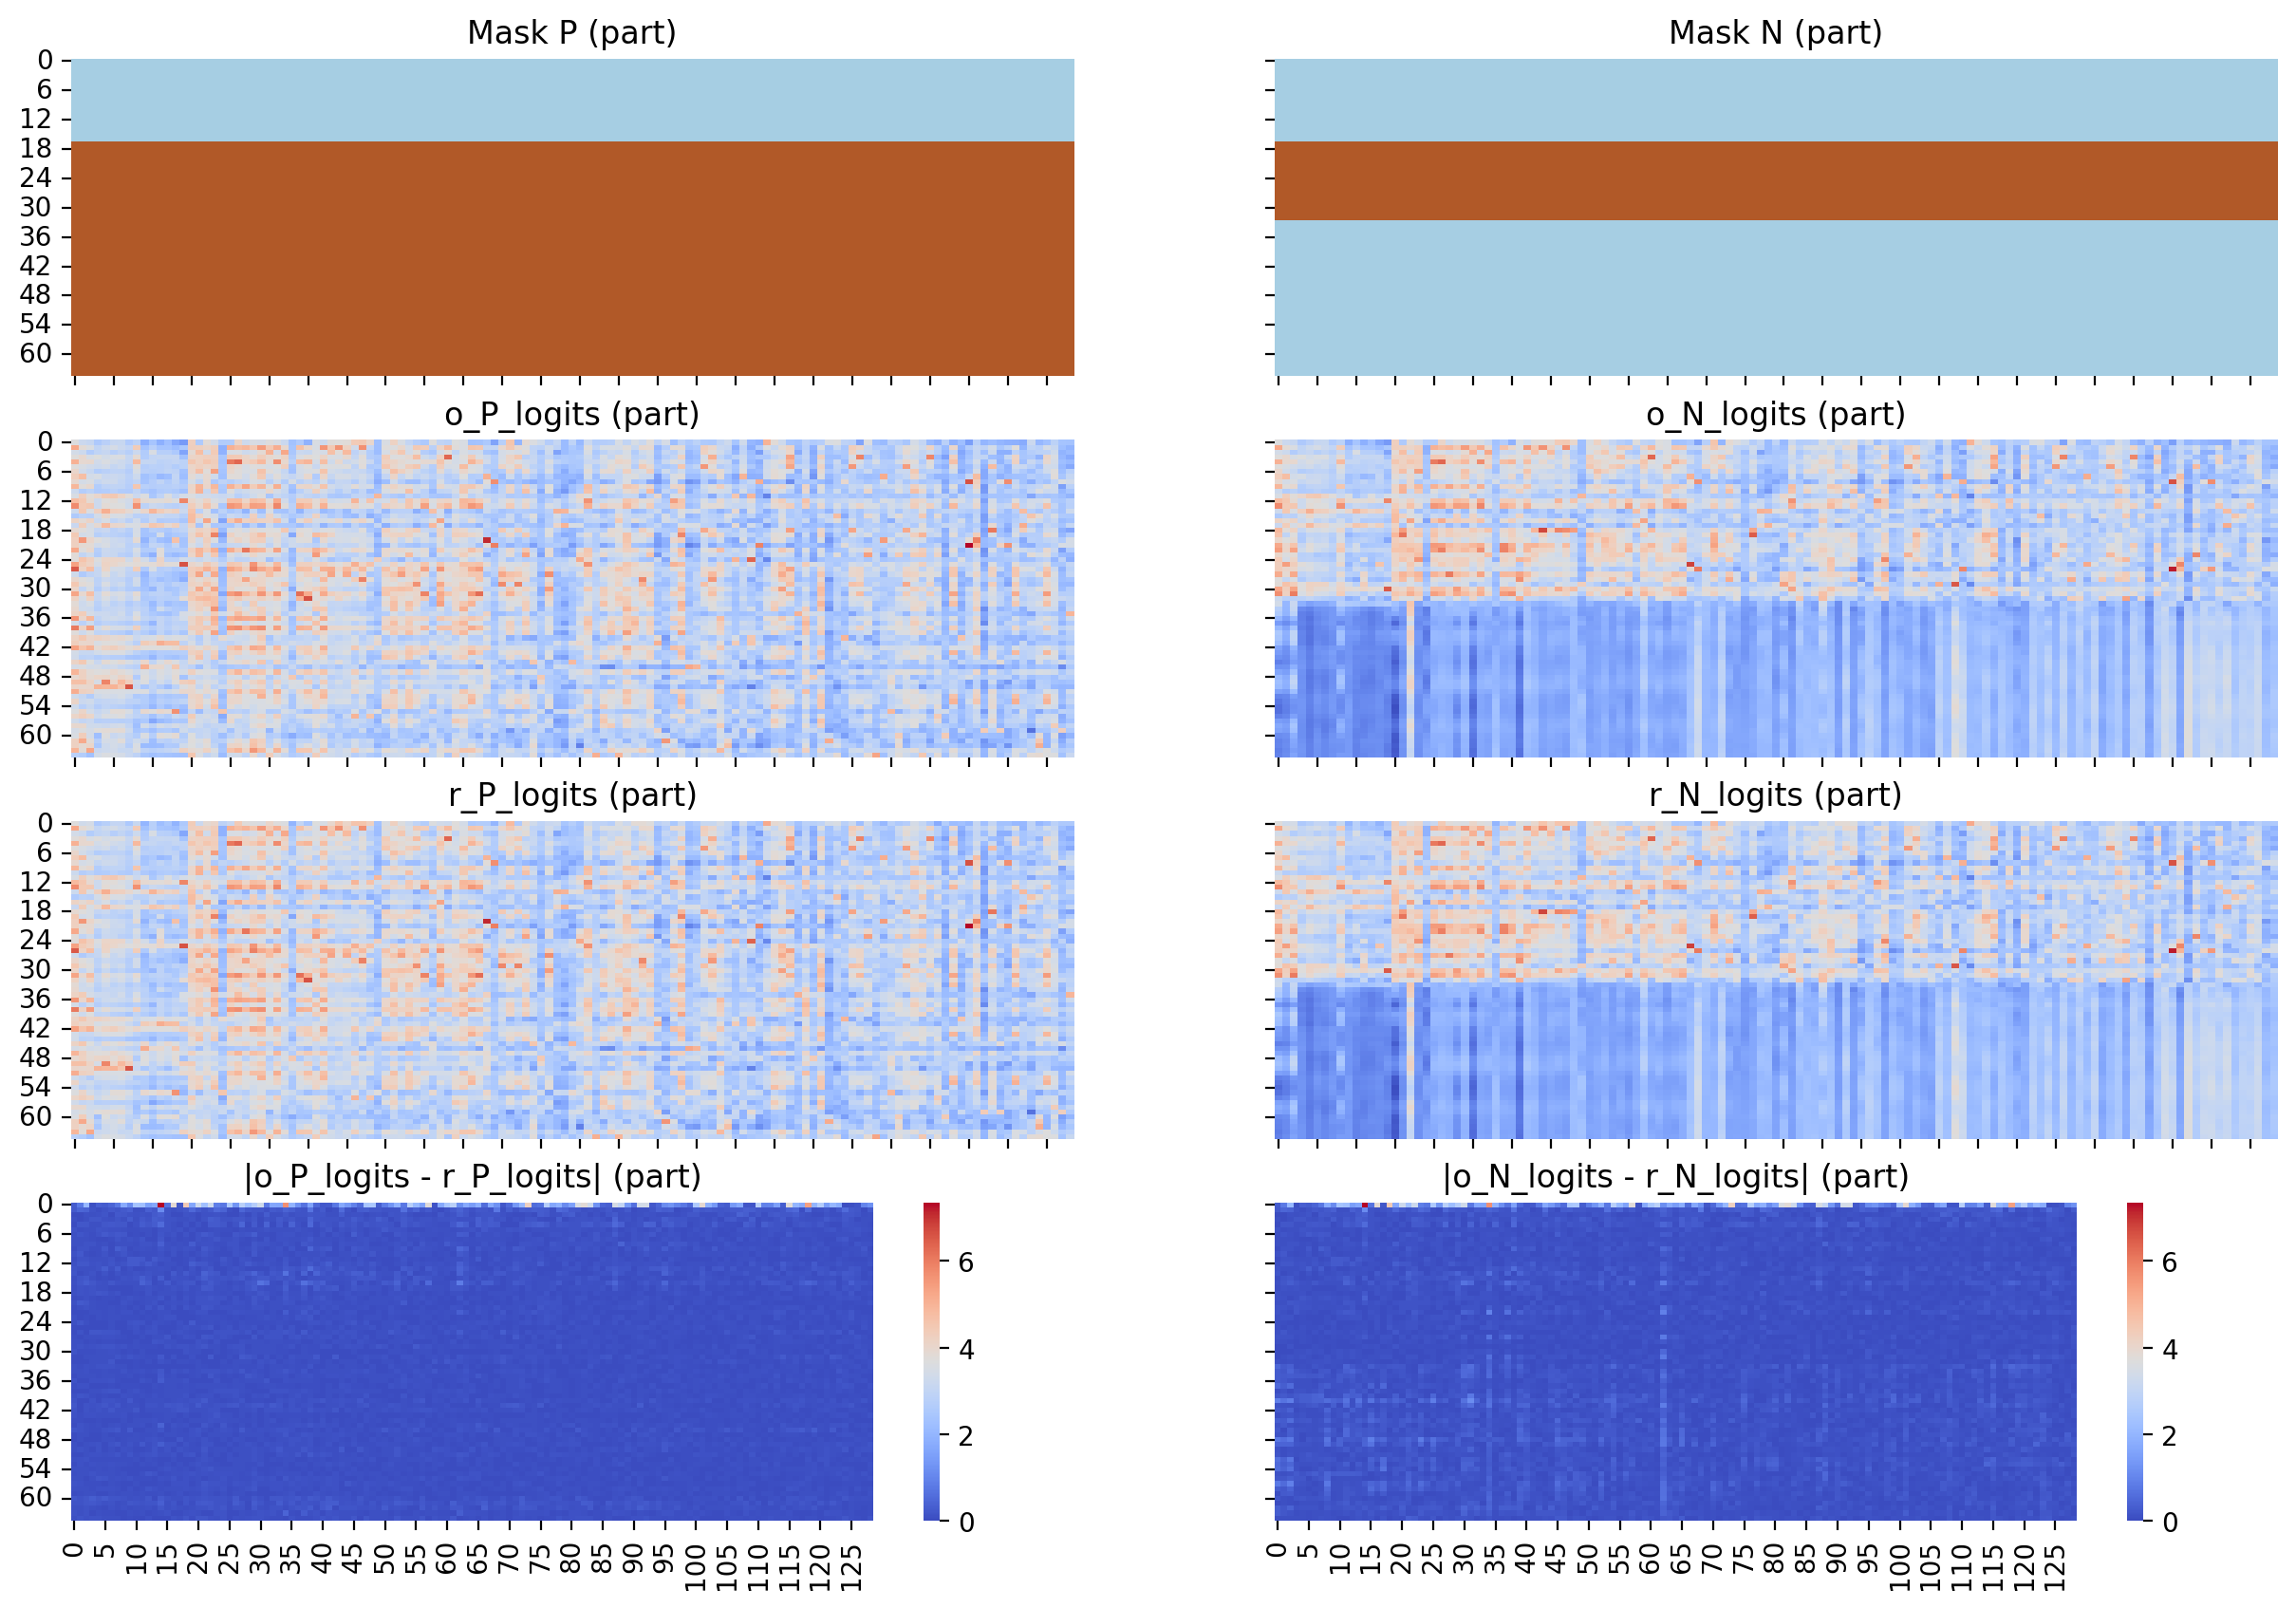

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(15, 10), sharex=True, sharey=True, dpi=200)
cmap_type = "coolwarm"
tmp = torch.concat(simple_list_logits)

norm = matplotlib.colors.Normalize(vmin=torch.min(tmp), vmax=torch.max(tmp))

sns.heatmap(mask_P.repeat(n_tokens, 1).T, ax=axes[0, 0], cmap="Paired", cbar=False)
axes[0, 0].set_title("Mask P (part)")
sns.heatmap(mask_N.repeat(n_tokens, 1).T, ax=axes[0, 1], cmap="Paired", cbar=False)
axes[0, 1].set_title("Mask N (part)")

sns.heatmap(simple_o_P_logits, ax=axes[1, 0], cmap=cmap_type, cbar=False, norm=norm)
axes[1, 0].set_title("o_P_logits (part)")
sns.heatmap(simple_o_N_logits, ax=axes[1, 1], cmap=cmap_type, cbar=False, norm=norm)
axes[1, 1].set_title("o_N_logits (part)")
sns.heatmap(simple_r_P_logits, ax=axes[2, 0], cmap=cmap_type, cbar=False, norm=norm)
axes[2, 0].set_title("r_P_logits (part)")
sns.heatmap(simple_r_N_logits, ax=axes[2, 1], cmap=cmap_type, cbar=False, norm=norm)
axes[2, 1].set_title("r_N_logits (part)")

sns.heatmap(
    torch.abs(simple_o_P_logits - simple_r_P_logits), ax=axes[3, 0], cmap=cmap_type
)
axes[3, 0].set_title("|o_P_logits - r_P_logits| (part)")
sns.heatmap(
    torch.abs(simple_o_N_logits - simple_r_N_logits), ax=axes[3, 1], cmap=cmap_type
)
axes[3, 1].set_title("|o_N_logits - r_N_logits| (part)")

### 3.2 loss 计算中间过程
 $[x||y_l]$、$[x||y_w]$ 投喂给两个模型 $\pi_\theta$、$\pi_\mathrm{ref}$ 后

分别生成对应的四种得分， 并将得分转换成概率分布：

$$
\begin{align*}
\pi_\theta(y_w|x)       &= \text{Softmax}\, \left(\text{o\_P\_logits}\right) \\
\pi_\theta(y_l|x)       &= \text{Softmax}\, \left(\text{o\_N\_logits}\right) \\
\pi_\mathrm{ref}(y_w|x) &= \text{Softmax}\, \left(\text{r\_P\_logits}\right) \\
\pi_\mathrm{ref}(y_l|x) &= \text{Softmax}\, \left(\text{r\_N\_logits}\right) \\
\end{align*}
$$

其具体分布如上图所示

其中 

$o_P$ 是 policy 模型的**正样本**输出概率云

$o_N$ 是 policy 模型的**负样本**输出概率云

---------


$r_P$ 是 ref 模型的**正样本**输出概率云

$r_N$ 是 ref 模型的**负样本**输出概率云

---------




In [ ]:
from rich.table import Table


def display_logits(title, tokens, out_logits, ref_logits, mask):
    table = Table(title=title)
    table.add_column("token")
    table.add_column("word")
    table.add_column("logits_o")
    table.add_column("ps_o")
    table.add_column("logits_r")
    table.add_column("ps_r")

    #! 每个 token 对应位置的 logits 其实是下一个位置 token 的得分，所以要做一个 offset
    _o_logits = out_logits[mask, :-1]
    _r_logits = ref_logits[mask, :-1]
    _tokens = tokens[mask][1:]
    _o_ps = F.softmax(_o_logits, dim=-1)
    _r_ps = F.softmax(_r_logits, dim=-1)
    print("softmax")
    print("rp_logps", _r_ps.shape)
    print("op_logps", _o_ps.shape)

    for token_i, logits_o_i, ps_o_i, logits_r_i, ps_r_i in zip(
        _tokens, _o_logits, _o_ps, _r_logits, _r_ps
    ):
        table.add_row(
            str(token_i.item()),
            tokenizer.decode(token_i),
            str(logits_o_i[token_i].item()),
            f"{ps_o_i[token_i].item()*100:02.3f}%",
            str(logits_r_i[token_i].item()),
            f"{ps_r_i[token_i].item()*100:02.3f}%",
        )
    rich.print(table)


display_logits("Chosen(Positive) Loss", P_tokens, o_P_logits, r_P_logits, mask_P)
display_logits("Rejected(Negative) Loss", N_tokens, o_N_logits, r_N_logits, mask_N)

softmax
rp_logps torch.Size([48, 151935])
op_logps torch.Size([48, 151935])


                      Chosen(Positive) Loss                       
┏━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ token ┃ word        ┃ logits_o  ┃ ps_o    ┃ logits_r ┃ ps_r    ┃
┡━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ 1249  │ To          │ 15.8125   │ 5.150%  │ 15.9375  │ 5.408%  │
│ 42780 │  accelerate │ 23.625    │ 95.184% │ 23.75    │ 95.655% │
│ 6915  │  fine       │ 22.125    │ 40.461% │ 22.25    │ 40.480% │
│ 2385  │ -t          │ 30.0      │ 99.923% │ 30.25    │ 99.938% │
│ 37202 │ uning       │ 31.625    │ 99.967% │ 31.75    │ 99.973% │
│ 315   │  of         │ 23.75     │ 97.638% │ 23.75    │ 97.708% │
│ 444   │  L          │ 19.875    │ 46.376% │ 20.0     │ 49.592% │
│ 10994 │ LM          │ 25.375    │ 99.903% │ 25.5     │ 99.906% │
│ 82    │ s           │ 27.0      │ 99.576% │ 27.0     │ 99.575% │
│ 11    │ ,           │ 26.25     │ 96.700% │ 26.25    │ 96.455% │
│ 825   │  one        │ 19.25     │ 7.968%  │ 19.25    │ 7.815%  │
│ 646   │  can        │ 22.625    │ 54.126% │ 22.625   │ 53.970% │
│ 4211  │  implement  │ 19.5      │ 2.328%  │ 19.625   │ 2.282%  │
│ 14830 │  strategies │ 17.125    │ 2.996%  │ 17.125   │ 3.020%  │
│ 1741  │  such       │ 24.625    │ 45.375% │ 24.625   │ 47.621% │
│ 438   │  as         │ 27.25     │ 99.985% │ 27.125   │ 99.983% │
│ 17719 │  reducing   │ 13.8125   │ 0.324%  │ 13.6875  │ 0.289%  │
│ 705   │  up         │ 8.5625    │ 0.000%  │ 8.625    │ 0.000%  │
│ 76332 │ casting     │ 11.0      │ 0.103%  │ 11.0     │ 0.101%  │
│ 315   │  of         │ 18.125    │ 4.808%  │ 18.125   │ 5.076%  │
│ 14324 │  weights    │ 16.25     │ 9.432%  │ 16.25    │ 9.316%  │
│ 2337  │  during     │ 20.5      │ 3.472%  │ 20.5     │ 3.535%  │
│ 1207  │  Q          │ 9.25      │ 0.002%  │ 9.3125   │ 0.002%  │
│ 4262  │ Lo          │ 7.15625   │ 0.005%  │ 7.1875   │ 0.005%  │
│ 5609  │ RA          │ 17.125    │ 23.205% │ 17.375   │ 27.638% │
│ 11    │ ,           │ 19.0      │ 43.362% │ 18.875   │ 40.571% │
│ 1667  │  using      │ 17.125    │ 14.758% │ 17.125   │ 14.777% │
│ 49457 │  Bits       │ 1.9296875 │ 0.000%  │ 1.859375 │ 0.000%  │
│ 437   │ and         │ 12.1875   │ 1.217%  │ 12.1875  │ 1.139%  │
│ 9651  │ bytes       │ 14.5      │ 1.186%  │ 14.4375  │ 1.049%  │
│ 293   │  b          │ 5.21875   │ 0.000%  │ 5.21875  │ 0.000%  │
│ 3649  │ float       │ 13.25     │ 5.907%  │ 13.3125  │ 6.030%  │
│ 16    │ 1           │ 22.25     │ 99.486% │ 22.125   │ 99.390% │
│ 21    │ 6           │ 26.875    │ 99.988% │ 26.875   │ 99.988% │
│ 11    │ ,           │ 17.5      │ 24.572% │ 17.5     │ 24.325% │
│ 323   │  and        │ 16.875    │ 31.775% │ 16.875   │ 31.975% │
│ 76482 │  leveraging │ 16.625    │ 10.021% │ 16.625   │ 10.698% │
│ 5355  │  Py         │ 12.4375   │ 1.157%  │ 12.375   │ 1.081%  │
│ 27414 │ torch       │ 16.0      │ 0.662%  │ 15.9375  │ 0.704%  │
│ 594   │ 's          │ 16.625    │ 74.352% │ 16.5     │ 72.092% │
│ 4937  │  fast       │ 9.875     │ 0.146%  │ 9.875    │ 0.143%  │
│ 328   │  S          │ 6.5625    │ 0.012%  │ 6.53125  │ 0.011%  │
│ 25228 │ caled       │ 10.75     │ 1.209%  │ 10.6875  │ 1.121%  │
│ 31262 │  Dot        │ 11.3125   │ 2.458%  │ 11.25    │ 2.220%  │
│ 5643  │  Product    │ 20.25     │ 82.803% │ 20.375   │ 82.751% │
│ 62020 │  Attention  │ 17.5      │ 77.225% │ 17.5     │ 76.326% │
│ 13    │ .           │ 18.375    │ 10.717% │ 18.25    │ 10.521% │
└───────┴─────────────┴───────────┴─────────┴──────────┴─────────┘

softmax
rp_logps torch.Size([16, 151935])
op_logps torch.Size([16, 151935])


                     Rejected(Negative) Loss                     
┏━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ token ┃ word        ┃ logits_o ┃ ps_o    ┃ logits_r ┃ ps_r    ┃
┡━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ 3862  │ There       │ 16.625   │ 11.606% │ 16.75    │ 12.187% │
│ 525   │  are        │ 28.0     │ 94.132% │ 28.125   │ 94.710% │
│ 902   │  no         │ 19.0     │ 0.069%  │ 19.125   │ 0.087%  │
│ 12538 │  techniques │ 14.875   │ 0.649%  │ 14.9375  │ 0.650%  │
│ 2500  │  available  │ 18.0     │ 0.896%  │ 18.125   │ 1.025%  │
│ 311   │  to         │ 22.875   │ 44.866% │ 22.875   │ 45.878% │
│ 42780 │  accelerate │ 22.125   │ 88.938% │ 22.125   │ 88.811% │
│ 6915  │  fine       │ 21.875   │ 78.510% │ 21.875   │ 76.443% │
│ 2385  │ -t          │ 28.375   │ 99.774% │ 28.5     │ 99.820% │
│ 37202 │ uning       │ 30.75    │ 99.919% │ 30.75    │ 99.912% │
│ 315   │  of         │ 23.25    │ 95.603% │ 23.125   │ 95.384% │
│ 444   │  L          │ 21.125   │ 88.778% │ 21.125   │ 88.859% │
│ 10994 │ LM          │ 26.5     │ 99.932% │ 26.625   │ 99.946% │
│ 82    │ s           │ 26.25    │ 99.622% │ 26.25    │ 99.624% │
│ 13    │ .           │ 23.0     │ 57.293% │ 23.125   │ 61.410% │
└───────┴─────────────┴──────────┴─────────┴──────────┴─────────┘

$$
\beta \log\frac{\pi^*\left(y_w|x\right)}{\pi_{\mathrm{ref}}\left(y_w|x\right)} - 
\beta \log\frac{\pi^*\left(y_l|x\right)}{\pi_{\mathrm{ref}}\left(y_l|x\right)}
\\
=\beta \left[
\textcolor{blue}{
\log\pi^*\left(y_w|x\right)
}

-
\textcolor{green}{
\log \pi_{\mathrm{ref}}\left(y_w|x\right)
}
+
\textcolor{orange}{
\log \pi^*\left(y_l|x\right)
}
-
\textcolor{red}{
\log \pi_{\mathrm{ref}}\left(y_l|x\right)
}
\right]

\\
=
\beta \left[
\textcolor{blue}{
logP_1
}

-
\textcolor{green}{
logP_2
}
+
\textcolor{orange}{
logP_3
}
-
\textcolor{red}{
logP_4
}
\right]
$$

In [ ]:
def get_logP(logits, labels, mask):
    _logits = logits[mask, :]
    _labels = labels[mask]
    _log_ps = F.log_softmax(_logits, dim=-1)
    select_logprobs = torch.gather(
        input=_log_ps, dim=-1, index=_labels.unsqueeze(1)
    ).squeeze(1)
    return select_logprobs.mean(-1)


logP1 = get_logP(o_P_logits, P_tokens, mask_P)
logP2 = get_logP(r_P_logits, P_tokens, mask_P)
logP3 = get_logP(o_N_logits, N_tokens, mask_N)
logP4 = get_logP(r_N_logits, N_tokens, mask_N)

print(f"{logP1.item()=:.5f}")
print(f"{logP2.item()=:.5f}")
print(f"{logP3.item()=:.5f}")
print(f"{logP4.item()=:.5f}")

logP1.item()=-14.37782
logP2.item()=-14.38225
logP3.item()=-15.84842
logP4.item()=-15.80615


### 3.3 计算最终 loss
$$
\text{Loss} =
- \ln \sigma
\left[
\beta

\textcolor{blue}{
logP_1
}

-
\textcolor{green}{
logP_2
}
+
\textcolor{orange}{
logP_3
}
-
\textcolor{red}{
logP_4
}

\right]
$$

In [29]:
def dpo_loss(
    policy_chosen_logps: torch.Tensor,
    policy_rejected_logps: torch.Tensor,
    reference_chosen_logps: torch.Tensor,
    reference_rejected_logps: torch.Tensor,
    beta=0.1,
):
    policy_logps = policy_chosen_logps - policy_rejected_logps
    reference_logps = reference_chosen_logps - reference_rejected_logps
    logits = policy_logps - reference_logps

    loss = -F.logsigmoid(beta * logits)

    # 下面两个用于追踪训练的进度
    chosen_rewards = (policy_chosen_logps - reference_chosen_logps).detach()
    rejected_rewards = (policy_rejected_logps - reference_rejected_logps).detach()

    # 对每个batch进行平均(期望)
    return loss.mean(), chosen_rewards.mean(), rejected_rewards.mean()

def sim_loss(
    policy_chosen_logps: torch.Tensor,
    policy_rejected_logps: torch.Tensor,
    beta=0.1,
    gamma: float = 0.5
):
    logits = policy_chosen_logps - policy_rejected_logps
    logits = logits - gamma
    loss = -F.logsigmoid(beta * logits)

    # 对每个batch进行平均(期望)
    return loss.mean()


loss_dpo, chosen_rewards, rejected_rewards = dpo_loss(logP1, logP2, logP3, logP4)
print(f"{loss_dpo.item()=}")

loss_simdpo = sim_loss(logP1, logP3)
print(f"{loss_simdpo.item()=}")

loss_dpo.item()=0.6908150315284729
loss_simdpo.item()=0.6457945108413696
